In [6]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import make_scorer, recall_score
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

from hatua_ml.data.load_kdhs import load_kdhs
from hatua_ml.features.ecdi2030 import ITEMS

df = load_kdhs()
complete = df.dropna(subset=ITEMS + ["on_track"])
X = complete[ITEMS + ["age_months"]].astype(float)
y = (1 - complete["on_track"]).astype(int)      # 1 = off track (the risk class)

print(f"loaded {len(df)}, complete cases {len(complete)}, off-track rate {y.mean():.1%}")

loaded 5478, complete cases 5195, off-track rate 29.4%


In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    "accuracy": "accuracy",
    "sensitivity": "recall",
    "specificity": make_scorer(recall_score, pos_label=0),
    "auc": "roc_auc",
}
models = {
    "logreg": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
    "xgboost": XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.1,
                             eval_metric="logloss", random_state=42),
}

rows = []
for name, model in models.items():
    s = cross_validate(model, X, y, cv=cv, scoring=scoring)
    rows.append({"model": name, **{k: s[f"test_{k}"].mean() for k in scoring}})
pd.DataFrame(rows).round(3)

,model,accuracy,sensitivity,specificity,auc
0,logreg,0.952,0.912,0.969,0.991
1,xgboost,0.979,0.954,0.989,0.998


In [9]:
from sklearn.tree import DecisionTreeClassifier, export_text

X_rule = pd.DataFrame({
    "items_passed": complete[ITEMS].astype(float).sum(axis=1),
    "age_months": complete["age_months"],
})
tree = DecisionTreeClassifier(max_depth=4, random_state=42)
s = cross_validate(tree, X_rule, y, cv=cv, scoring=scoring)
print({k: round(s[f"test_{k}"].mean(), 3) for k in scoring})

tree.fit(X_rule, y)
print(export_text(tree, feature_names=list(X_rule.columns)))

{'accuracy': np.float64(0.912), 'sensitivity': np.float64(0.885), 'specificity': np.float64(0.923), 'auc': np.float64(0.968)}
|--- items_passed <= 14.50
|   |--- age_months <= 47.50
|   |   |--- items_passed <= 8.50
|   |   |   |--- age_months <= 29.50
|   |   |   |   |--- class: 1
|   |   |   |--- age_months >  29.50
|   |   |   |   |--- class: 1
|   |   |--- items_passed >  8.50
|   |   |   |--- age_months <= 41.50
|   |   |   |   |--- class: 0
|   |   |   |--- age_months >  41.50
|   |   |   |   |--- class: 1
|   |--- age_months >  47.50
|   |   |--- class: 1
|--- items_passed >  14.50
|   |--- class: 0



In [10]:
from hatua_ml.features.ecdi2030 import cutoff_for_age

margin = complete[ITEMS].astype(float).fillna(0).sum(axis=1) - cutoff_for_age(complete["age_months"])
X_margin = margin.to_frame("margin")

stump = DecisionTreeClassifier(max_depth=1, random_state=42)
s = cross_validate(stump, X_margin, y, cv=cv, scoring=scoring)
print({k: round(s[f"test_{k}"].mean(), 3) for k in scoring})

stump.fit(X_margin, y)
print(export_text(stump, feature_names=["margin"]))

{'accuracy': np.float64(1.0), 'sensitivity': np.float64(1.0), 'specificity': np.float64(1.0), 'auc': np.float64(1.0)}
|--- margin <= -0.50
|   |--- class: 1
|--- margin >  -0.50
|   |--- class: 0



**Finding:** the on_track label is a deterministic function of the inputs
(items passed minus the age-band cutoff). A one-split tree on this margin scores 1.000
on every metric. Models trained on all 20 items therefore reconstruct the ECDI2030
scoring rule rather than predict development. This motivates the item-reduction question.

In [11]:
from sklearn.model_selection import train_test_split, cross_val_score

LABELS = {
    "ecd21": "walks on uneven surface", "ecd22": "jumps with both feet", "ecd23": "dresses self",
    "ecd24": "fastens buttons", "ecd25": "says 10+ words", "ecd26": "3-word sentences",
    "ecd27": "5-word sentences", "ecd28": "uses I/you/he/she", "ecd29": "names familiar object",
    "ecd30": "recognises 5 letters", "ecd31": "writes own name", "ecd32": "recognises numbers 1-5",
    "ecd33": "gives 3 objects when asked", "ecd34": "counts 10 objects", "ecd35": "persists at play task",
    "ecd36": "asks about familiar people", "ecd37": "offers help", "ecd38": "gets along with children",
    "ecd39": "rarely sad", "ecd40": "not aggressive",
}

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

def lr():
    return make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))

selected, remaining, path = [], list(ITEMS), []
while remaining:
    scores = {
        item: cross_val_score(lr(), X_tr[selected + [item, "age_months"]], y_tr,
                              cv=cv, scoring="roc_auc").mean()
        for item in remaining
    }
    best = max(scores, key=scores.get)
    selected.append(best)
    remaining.remove(best)
    path.append({"k": len(selected), "added": best, "question": LABELS[best], "cv_auc": scores[best]})

order = pd.DataFrame(path)
order.round(3)

,k,added,question,cv_auc
0,1,ecd32,recognises numbers 1-5,0.789
1,2,ecd27,5-word sentences,0.866
2,3,ecd29,names familiar object,0.895
3,4,ecd24,fastens buttons,0.918
4,5,ecd37,offers help,0.932
5,6,ecd33,gives 3 objects when asked,0.942
6,7,ecd35,persists at play task,0.949
7,8,ecd40,not aggressive,0.956
8,9,ecd36,asks about familiar people,0.961
9,10,ecd22,jumps with both feet,0.966


In [12]:
import numpy as np
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import cross_val_predict

TARGET_SENS = 0.90
rows = []
for k in range(1, len(order) + 1):
    cols = list(order["added"][:k]) + ["age_months"]

    # choose the cut-off using training children only
    p_tr = cross_val_predict(lr(), X_tr[cols], y_tr, cv=cv, method="predict_proba")[:, 1]
    threshold = np.quantile(p_tr[y_tr == 1], 1 - TARGET_SENS)

    # then judge it on the unseen test children
    model = lr().fit(X_tr[cols], y_tr)
    p_te = model.predict_proba(X_te[cols])[:, 1]
    flagged = p_te >= threshold
    yt = y_te.to_numpy()
    rows.append({
        "k": k,
        "auc": roc_auc_score(yt, p_te),
        "sensitivity": flagged[yt == 1].mean(),
        "specificity": (~flagged[yt == 0]).mean(),
    })

curve = pd.DataFrame(rows)
curve.round(3)

,k,auc,sensitivity,specificity
0,1,0.795,0.948,0.460
1,2,0.883,0.931,0.657
2,3,0.917,0.938,0.729
3,4,0.935,0.938,0.766
4,5,0.951,0.931,0.809
5,6,0.955,0.918,0.842
6,7,0.962,0.944,0.847
7,8,0.968,0.931,0.862
8,9,0.972,0.918,0.903
9,10,0.975,0.921,0.906


Matplotlib is building the font cache; this may take a moment.


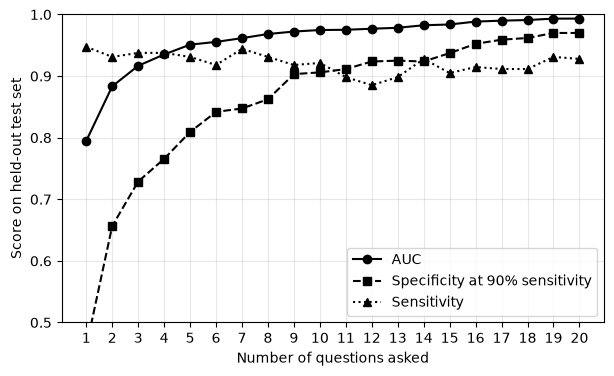

In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(curve.k, curve.auc, "k-o", label="AUC")
ax.plot(curve.k, curve.specificity, "k--s", label="Specificity at 90% sensitivity")
ax.plot(curve.k, curve.sensitivity, "k:^", label="Sensitivity")
ax.set_xlabel("Number of questions asked")
ax.set_ylabel("Score on held-out test set")
ax.set_xticks(range(1, 21))
ax.set_ylim(0.5, 1.0)
ax.grid(alpha=0.3)
ax.legend()
fig.savefig("../reports/figures/item_reduction_curve.png", dpi=200, bbox_inches="tight")

**Item reduction (KDHS 2022, held-out 20%, 90% target sensitivity):**
9 items retain ~92% sensitivity with 90% specificity, versus 97% specificity with all 20.
Top 9 in order: ecd32, ecd27, ecd29, ecd24, ecd37, ecd33, ecd35, ecd40, ecd36.
Caveats: target is the ECDI2030 classification, single country, single split.